# Install libraries

In [1]:
!pip install pandas numpy matplotlib --quiet

Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


Upload datasets

In [4]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


# Load datasets

In [5]:

app_event = pd.read_csv("app_events.csv")
complaint = pd.read_csv("complaints.csv")
customer = pd.read_csv("customers.csv")
data_dictionary = pd.read_csv("data_dictionary.csv")
drivers = pd.read_csv("drivers.csv")
hubs = pd.read_csv("hubs.csv")
incidents = pd.read_csv("incidents.csv")
orders = pd.read_csv("orders.csv")
vehicle = pd.read_csv("vehicles.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


# Data Preparation

Standardise zone names

In [6]:
def clean_zone(col):
    return col.str.strip().str.upper()

customer["home_zone"] = clean_zone(customer["home_zone"])
drivers["base_zone"] = clean_zone(drivers["base_zone"])
orders["pickup_zone"] = clean_zone(orders["pickup_zone"])
orders["dropoff_zone"] = clean_zone(orders["dropoff_zone"])
vehicle["assigned_zone"] = clean_zone(vehicle["assigned_zone"])
hubs["zone"] = clean_zone(hubs["zone"])
app_event["zone_context"] = clean_zone(app_event["zone_context"])

print("Zone values standardised")

Zone values standardised


Convert date columns

In [7]:
orders["order_created_at"] = pd.to_datetime(orders["order_created_at"])
complaint["created_at"] = pd.to_datetime(complaint["created_at"])
app_event["event_timestamp"] = pd.to_datetime(app_event["event_timestamp"])
vehicle["commission_date"] = pd.to_datetime(vehicle["commission_date"])
incidents["reported_at"] = pd.to_datetime(incidents["reported_at"])

print("Dates converted")

Dates converted


# Analysis 1 – High value customers

identify customers generating high revenue

customer_id
C0545    923.45
C0157    720.04
C0622    701.21
C0343    685.78
C0372    669.11
C0013    659.26
C0558    605.85
C0289    601.81
C0301    592.99
C0476    587.86
Name: order_value, dtype: float64


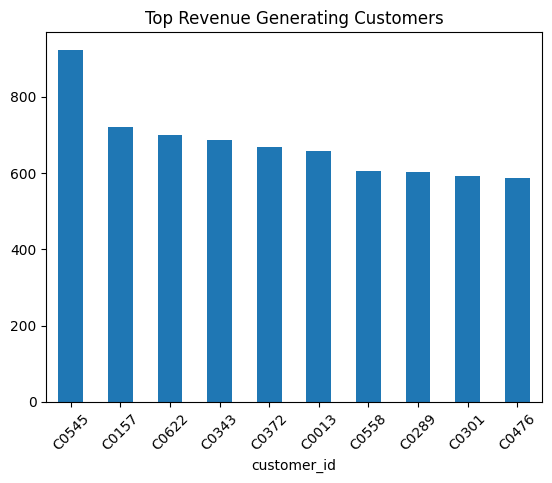

In [8]:
customer_orders = pd.merge(customer, orders, on="customer_id")

high_value = customer_orders.groupby("customer_id")["order_value"].sum().sort_values(ascending=False).head(10)

print(high_value)

plt.figure()
high_value.plot(kind="bar")
plt.title("Top Revenue Generating Customers")
plt.xticks(rotation=45)
plt.show()

# Analysis 2 – Order complexity risk

orders with special handling may cause delays

special_handling_flag
0    92.302688
1    85.726176
Name: order_value, dtype: float64


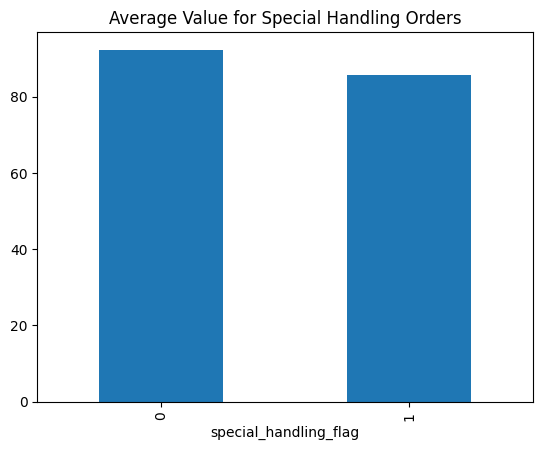

In [9]:
complex_orders = orders.groupby("special_handling_flag")["order_value"].mean()

print(complex_orders)

plt.figure()
complex_orders.plot(kind="bar")
plt.title("Average Value for Special Handling Orders")
plt.show()

# Analysis 3 – Zone demand imbalance

identify zones with uneven demand

pickup_zone
EAST         207
SOUTH        181
NORTH        174
CENTRAL      158
WEST         155
RIVERSIDE    151
AIRPORT      144
CTR           80
dtype: int64


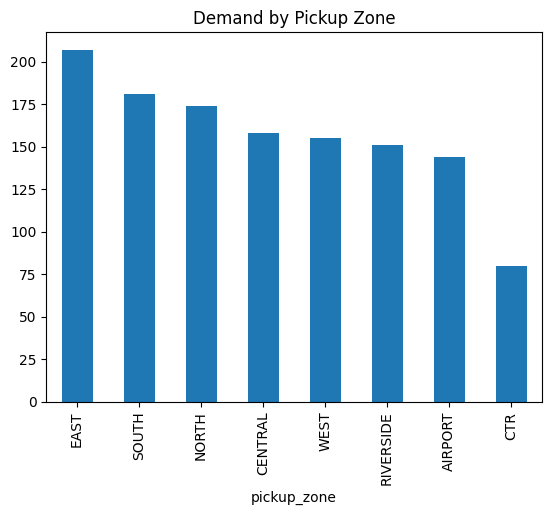

In [10]:
zone_demand = orders.groupby("pickup_zone").size().sort_values(ascending=False)

print(zone_demand)

plt.figure()
zone_demand.plot(kind="bar")
plt.title("Demand by Pickup Zone")
plt.show()

# Analysis 4 – Driver experience vs rating

does experience improve performance

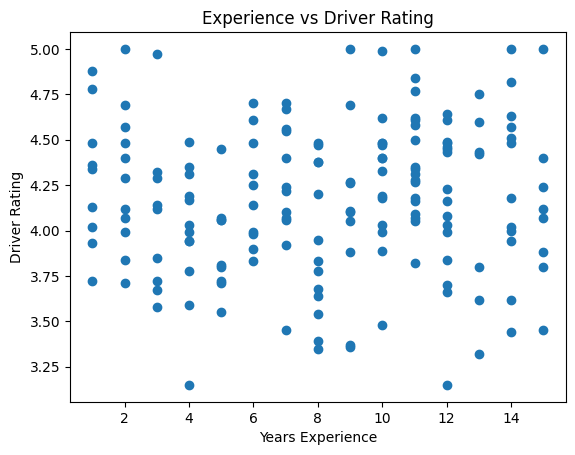

Correlation: 0.06284003602730807


In [11]:
plt.figure()
plt.scatter(drivers["years_experience"], drivers["driver_rating"])

plt.title("Experience vs Driver Rating")
plt.xlabel("Years Experience")
plt.ylabel("Driver Rating")
plt.show()

correlation = drivers["years_experience"].corr(drivers["driver_rating"])

print("Correlation:", correlation)

# Analysis 5 – Vehicle usage intensity

high odometer vehicles may require maintenance

   vehicle_id  odometer_km
2        V003       219359
63       V064       219116
64       V065       217057
41       V042       215870
35       V036       215767


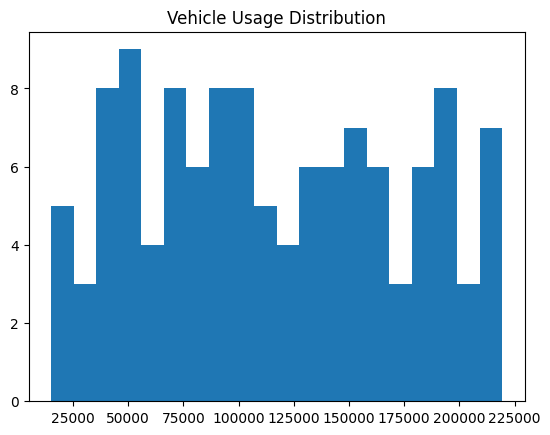

In [12]:
vehicle_usage = vehicle.sort_values("odometer_km", ascending=False)

print(vehicle_usage[["vehicle_id","odometer_km"]].head())

plt.figure()
plt.hist(vehicle["odometer_km"], bins=20)

plt.title("Vehicle Usage Distribution")
plt.show()

# Analysis 6 – Incident severity impact

understand operational risk

severity
Critical    11.442308
High        11.154839
Low         13.577922
Medium      11.473469
Name: resolved_hours, dtype: float64


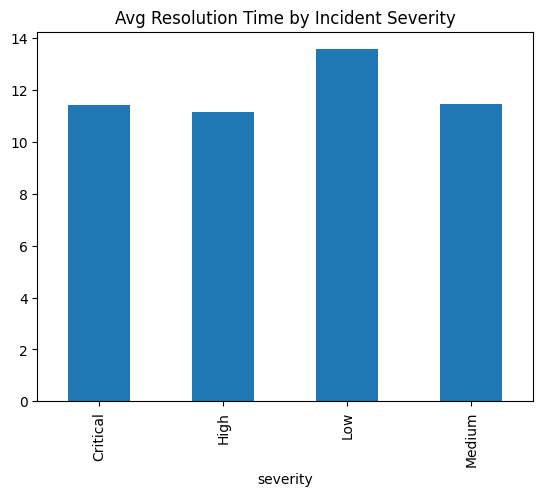

In [13]:
incident_severity = incidents.groupby("severity")["resolved_hours"].mean()

print(incident_severity)

plt.figure()
incident_severity.plot(kind="bar")

plt.title("Avg Resolution Time by Incident Severity")
plt.show()

# Analysis 7 – Customer digital behaviour

identify preferred interaction channels

preferred_channel
App            367
Web            139
Phone          104
Partner API     27
Name: count, dtype: int64


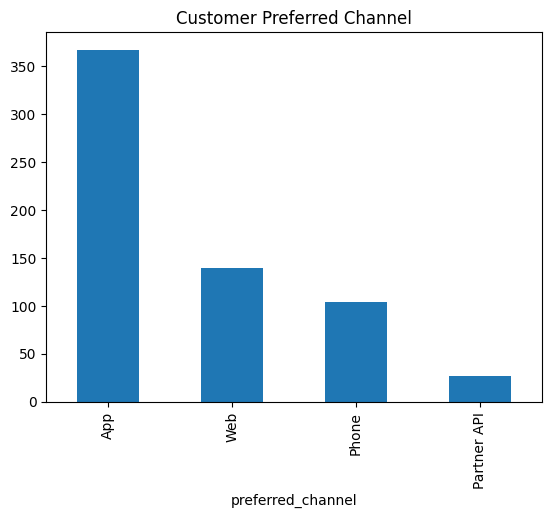

In [14]:
channel_pref = customer["preferred_channel"].value_counts()

print(channel_pref)

plt.figure()
channel_pref.plot(kind="bar")

plt.title("Customer Preferred Channel")
plt.show()

# Analysis 8 – App failure risk

unsuccessful app events indicate system problems

device_type
Android    0.933333
Web        0.934783
iOS        0.952790
Name: success_flag, dtype: float64


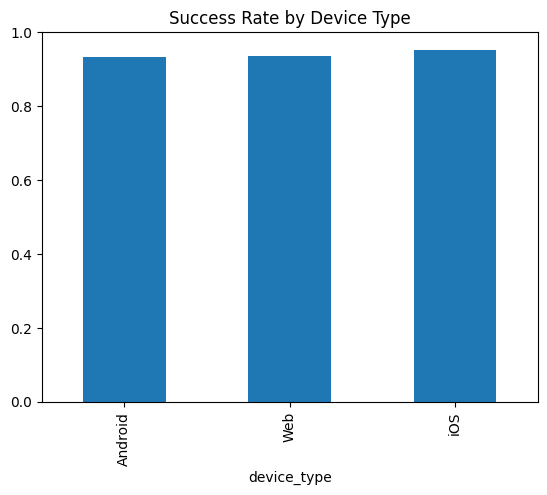

In [15]:
failure_rate = app_event.groupby("device_type")["success_flag"].mean()

print(failure_rate)

plt.figure()
failure_rate.plot(kind="bar")

plt.title("Success Rate by Device Type")
plt.show()

# Analysis 9 – Order urgency pressure

short promised windows create operational pressure

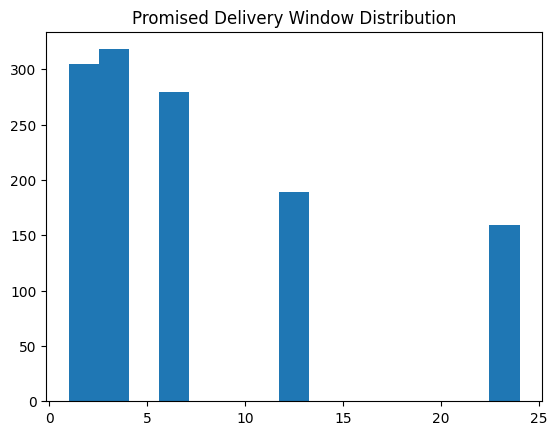

count    1250.000000
mean        7.621600
std         7.057015
min         1.000000
25%         4.000000
50%         6.000000
75%        12.000000
max        24.000000
Name: promised_window_hours, dtype: float64


In [16]:
plt.figure()
plt.hist(orders["promised_window_hours"], bins=15)

plt.title("Promised Delivery Window Distribution")
plt.show()

print(orders["promised_window_hours"].describe())

# Analysis 10 – Hub capacity vs demand

Analysis 10 – Hub capacity vs demand

hub_name
Airport Hub       144
Central Core      158
East Dock         207
Midtown Relay     158
North Exchange    174
Riverside Hub     151
South Link        181
West Gate         155
dtype: int64


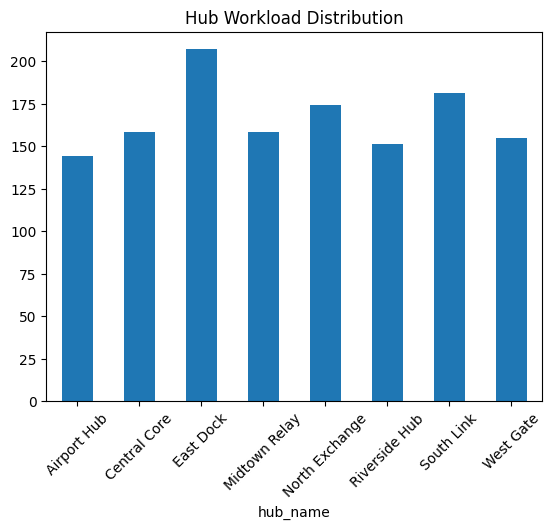

In [17]:
hub_orders = pd.merge(hubs, orders, left_on="zone", right_on="pickup_zone")

hub_load = hub_orders.groupby("hub_name").size()

print(hub_load)

plt.figure()
hub_load.plot(kind="bar")

plt.title("Hub Workload Distribution")
plt.xticks(rotation=45)
plt.show()